# Clase 5 · Probabilidad e inferencia: ¿real o azar?

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

**Descriptiva e inferencia.** En las clases 2 a 4 hicimos estadística descriptiva: resumir y graficar la tabla que tenemos, con números que hablan solo de esas filas. La **inferencia estadística** usa esos mismos datos para hablar de la población de la que salieron, y dice cuánta incertidumbre trae esa afirmación. Hace dos preguntas: ¿cuánto vale? (estimación, con un intervalo) y ¿es real o azar? (prueba de hipótesis, con un valor p). La probabilidad es el lenguaje de esa incertidumbre; por eso va primero.

**Por qué aparece la distribución normal.** No porque los datos sean normales (la duración de los viajes no lo es), sino porque los promedios lo son: si repitiéramos la muestra muchas veces, la media y la pendiente se repartirían como una campana alrededor del valor real (el teorema central del límite, sección 3). De esa campana sale el 1,96 que construye el intervalo de confianza y el valor p.

**El hilo de la clase:** todo número que sale de una muestra se mueve de muestra en muestra. Inferir es medir ese movimiento (el error estándar) y usarlo de dos formas: como rango (el intervalo de confianza) y como contraste (la prueba de hipótesis y el valor p). Primero con la media de la duración, donde podemos ver el movimiento porque tenemos la población; después con la pendiente de las comunas, donde lo vemos remuestreando (bootstrap) y con la fórmula de statsmodels.

**La pregunta de la clase:** ¿cuánto se movería este número con otra muestra?

## 1. Preparación

Hoy la EOD cumple un papel nuevo: trataremos sus 113 mil viajes **como si fueran la población completa** de viajes de Santiago. Es una ficción didáctica, pero permite hacer lo que en la realidad nunca se puede: tomar muchas muestras de la población y mirar cómo cambian los resultados entre una y otra. Por lo mismo, en esta parte no ponderamos: la población es la tabla tal cual.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
# scipy.stats: las distribuciones de probabilidad con nombre
from scipy import stats

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Si clonó el repositorio del curso, los datos ya están en su disco:
# BASE = "datos/eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

# La población de hoy: la duración de cada viaje, sin faltantes ni ceros
duracion = viajes["TiempoViaje"].dropna()
duracion = duracion[duracion > 0]
len(duracion)

113113

## 2. El azar tiene forma: variables aleatorias y distribuciones

**Objetivo:** ponerle nombre a algo que ya usamos: la duración de un viaje es una **variable aleatoria**, y su histograma es su **distribución**.

Una variable aleatoria es una cantidad cuyo valor depende del azar: la duración del próximo viaje que registre la encuesta puede ser 10 minutos o 90, y no lo sabemos de antemano. Su **distribución** dice qué valores puede tomar y con qué frecuencia; para una población completa, es exactamente el histograma. Y la **esperanza** $E[X]$ es la media de esa distribución: el valor promedio que esperaríamos a la larga. La **varianza** mide cuánto se dispersa alrededor de la esperanza. Son los mismos resúmenes de la clase 2, ahora vistos como propiedades de la población y no de una muestra.

In [4]:
print("Esperanza (media poblacional):", round(duracion.mean(), 2), "min")
print("Mediana:", duracion.median(), "min")
print("Desviación estándar:", round(duracion.std(), 2), "min")
print("Asimetría:", round(duracion.skew(), 2))

Esperanza (media poblacional): 36.93 min
Mediana: 30.0 min
Desviación estándar: 36.05 min
Asimetría: 5.3


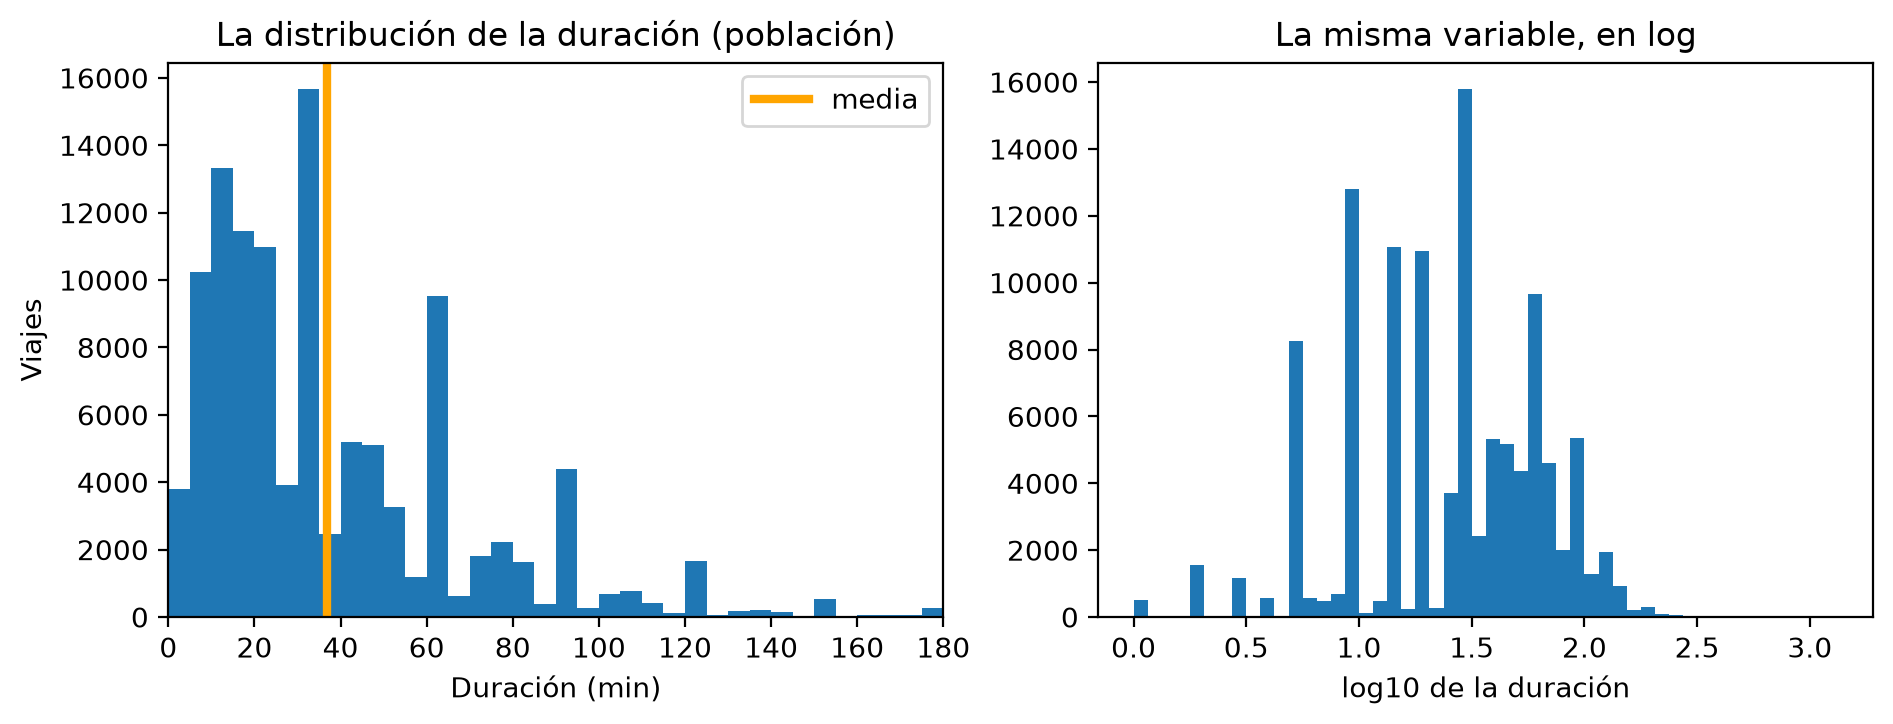

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(duracion, bins=range(0, 181, 5))
axes[0].axvline(duracion.mean(), color="orange", lw=3, label="media")
axes[0].set(xlim=(0, 180), xlabel="Duración (min)", ylabel="Viajes",
            title="La distribución de la duración (población)")
axes[0].legend()
axes[1].hist(np.log10(duracion), bins=50)
axes[1].set(xlabel="log10 de la duración", title="La misma variable, en log")
plt.show()

Hay otra variable aleatoria que nos va a importar más que la duración de un viaje: la **media de 100 viajes tomados al azar**, que depende de qué viajes cayeron en la muestra. Su distribución, como veremos en la sección 3, tiene forma de campana. Y esa campana tiene nombre.

### Las distribuciones con nombre

Algunas formas aparecen tanto que tienen nombre y fórmula. La más importante es la **normal**, $X \sim N(\mu, \sigma^2)$: la campana simétrica, definida por dos parámetros: $\mu$, la media (el centro de la campana), y $\sigma$, la desviación estándar (su ancho). Su regla práctica: el 68% de los valores cae a menos de una $\sigma$ de la media, el 95% a menos de $1{,}96\,\sigma$ y el 99,7% a menos de $3\sigma$. La normal importa aquí no porque los datos la sigan, sino porque, como veremos en la sección 3, los promedios la siguen. Ese 1,96 va a reaparecer en los intervalos de confianza.

La duración en minutos no es normal (cola larga, asimetría 5,3), pero en log se parece bastante. Comparemos cada histograma con la normal que tiene su misma media y desviación:

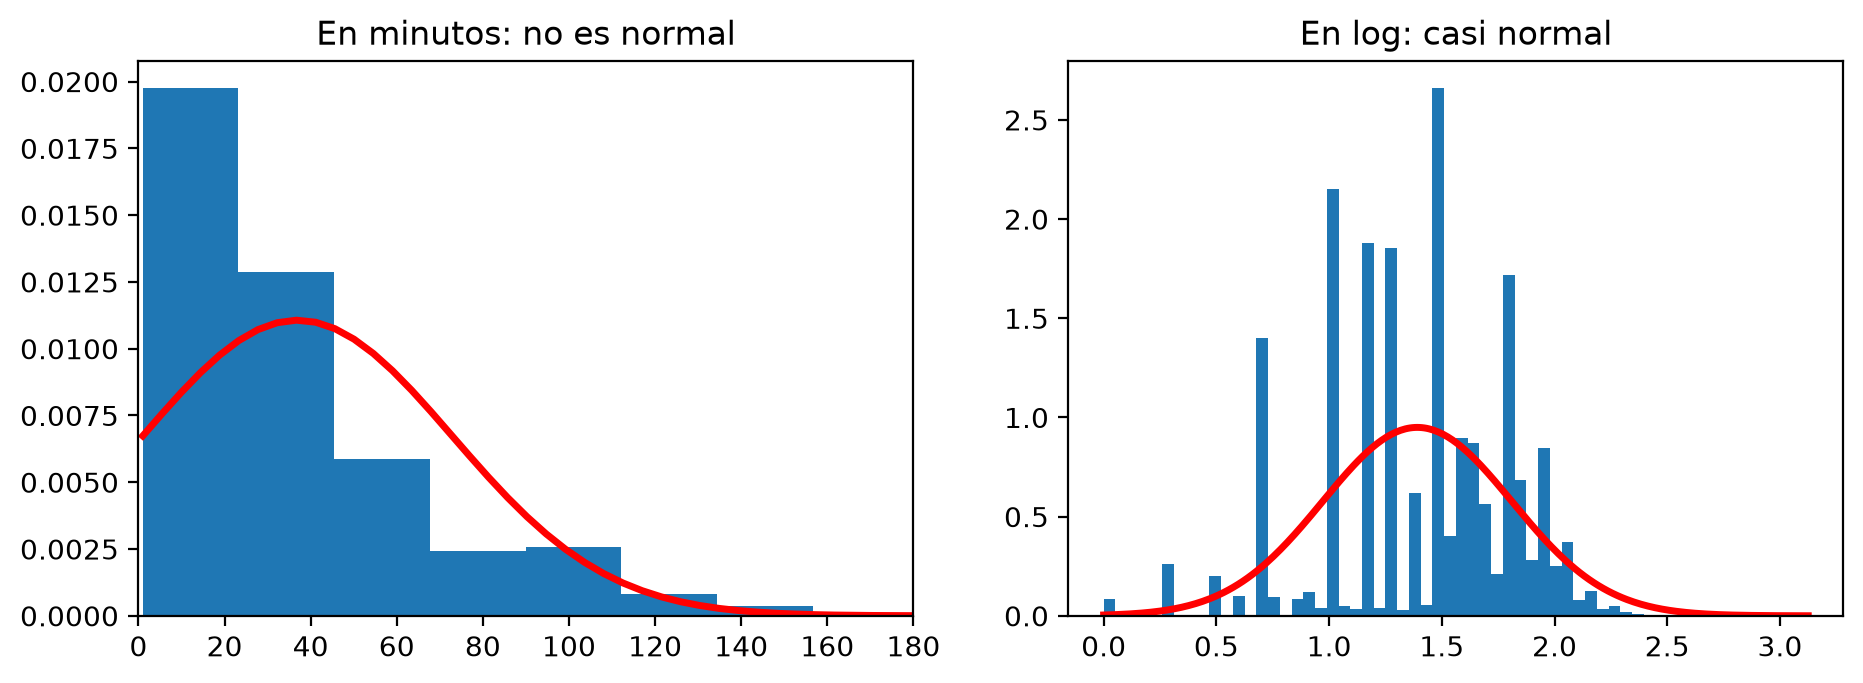

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, x, titulo in [(axes[0], duracion, "En minutos: no es normal"),
                      (axes[1], np.log10(duracion), "En log: casi normal")]:
    ax.hist(x, bins=60, density=True)
    grilla = np.linspace(x.min(), x.max(), 300)
    # stats.norm.pdf: la curva de la normal con esa media y esa sd
    ax.plot(grilla, stats.norm.pdf(grilla, x.mean(), x.std()), color="red", lw=2.5)
    ax.set_title(titulo)
axes[0].set_xlim(0, 180)
plt.show()

Esto explica dos cosas de la clase 4: por qué el log ayudó a la regresión (en log la variable se comporta como una normal) y por qué la normal aparece en todas partes: cuando muchas causas pequeñas se suman, el resultado tiende a ser normal. Eso último es un teorema, y lo veremos actuar en la próxima sección.

## 3. Un número se mueve: la distribución muestral

**Objetivo:** ver con los propios ojos cuánto cambia un resultado (la media) de una muestra a otra.

En la vida real solo tenemos una muestra. Aquí tenemos la población, así que podemos tomar una muestra de 100 viajes, calcular su media, y repetirlo:

In [7]:
# Un generador de números aleatorios con semilla: los resultados se repiten
rng = np.random.default_rng(42)

for i in range(5):
    muestra = rng.choice(duracion, 100)
    print(f"muestra {i + 1}: media = {muestra.mean():.1f} min")
print("media de la población:", round(duracion.mean(), 1))

muestra 1: media = 33.8 min
muestra 2: media = 37.9 min
muestra 3: media = 36.9 min
muestra 4: media = 40.2 min
muestra 5: media = 36.6 min
media de la población: 36.9


Cada muestra da una media distinta, y ninguna es exactamente la poblacional. ¿Cuánto se mueven? Tomemos 2.000 muestras y miremos el histograma de sus medias: esa es la **distribución muestral** de la media, y su desviación estándar se llama **error estándar**:

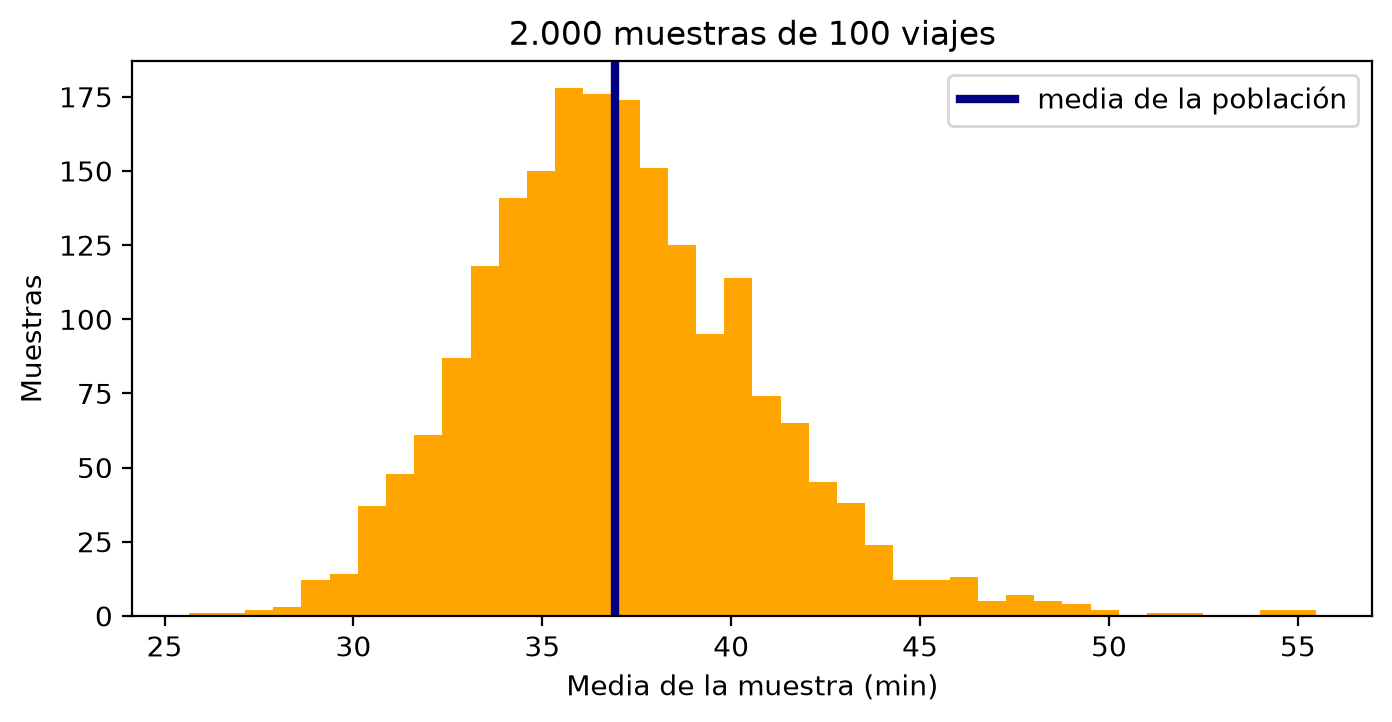

Error estándar (sd de las 2000 medias): 3.73
sigma / raíz de n, con la población: 3.6
s / raíz de n, con una sola muestra: 2.75


In [8]:
medias = np.array([rng.choice(duracion, 100).mean() for _ in range(2000)])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(medias, bins=40, color="orange")
ax.axvline(duracion.mean(), color="navy", lw=3, label="media de la población")
ax.set(xlabel="Media de la muestra (min)", ylabel="Muestras",
       title="2.000 muestras de 100 viajes")
ax.legend()
plt.show()

print("Error estándar (sd de las 2000 medias):", round(medias.std(), 2))
print("sigma / raíz de n, con la población:", round(duracion.std() / np.sqrt(100), 2))

# La vida real: una sola muestra, sin ver la población
una_muestra = rng.choice(duracion, 100)
print("s / raíz de n, con una sola muestra:", round(una_muestra.std(ddof=1) / np.sqrt(100), 2))

**Desviación estándar y error estándar no son lo mismo.** La desviación estándar de la duración (36 minutos) dice cuánto varía la duración de un viaje a otro: describe los datos. El error estándar (3,6 minutos) dice cuánto varía la media de una muestra a otra: describe el estimador, y es la desviación estándar de la distribución muestral. Por eso es mucho más chico, y baja cuando la muestra crece. En la misma escala:

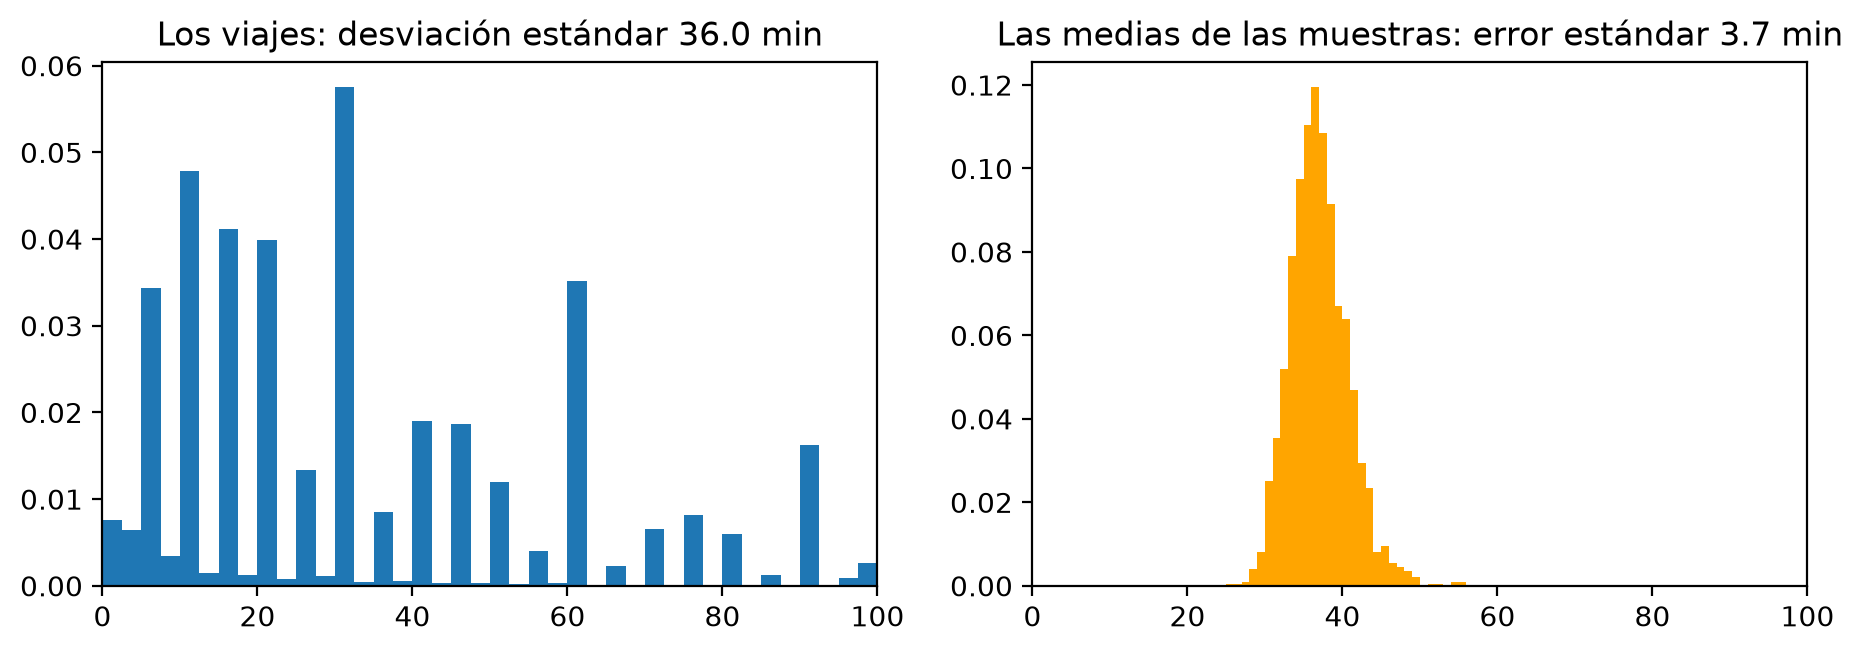

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True)
axes[0].hist(duracion, bins=np.arange(0, 101, 2.5), density=True)
axes[0].set_title(f"Los viajes: desviación estándar {duracion.std():.1f} min")
axes[1].hist(medias, bins=np.arange(0, 101, 1), density=True, color="orange")
axes[1].set_title(f"Las medias de las muestras: error estándar {medias.std():.1f} min")
axes[1].set_xlim(0, 100)
plt.show()

Los dos primeros números coinciden. El tercero se parece más o menos según la muestra que tocó: con una variable de cola tan larga, una muestra de 100 puede dejar fuera los viajes muy largos y subestimar la desviación. Esa es la fórmula del **error estándar** de la media:

$$EE(\bar{x}) = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}$$

donde $\sigma$ es la desviación estándar de la duración en la población (los 113 mil viajes) y $n$ el tamaño de la muestra. **Decisión:** $\sigma$ no la conocemos, porque es de la población; la reemplazamos por $s$, la misma desviación estándar de la duración pero calculada en la única muestra que tenemos. Las dos miden lo mismo, cuánto varía la duración de un viaje a otro. Con $n$ grande da lo mismo; con $n$ chico, casi (de eso se encarga la $t$ de Student, en la sección 6). Las 2.000 muestras fueron posibles porque aquí tenemos la población; en la vida real hay una sola muestra, y la fórmula da el error estándar desde ella. Dice cuánto se mueve la media de una muestra a otra, y que para reducirla a la mitad hay que cuadruplicar la muestra.

### El teorema central del límite

**Objetivo:** ver por qué la distribución muestral tiene forma de normal aunque la duración no la tenga.

Repitamos el experimento con muestras de 30, 100 y 500 viajes, y sobre cada histograma dibujemos la normal con media poblacional y desviación $\sigma/\sqrt{n}$:

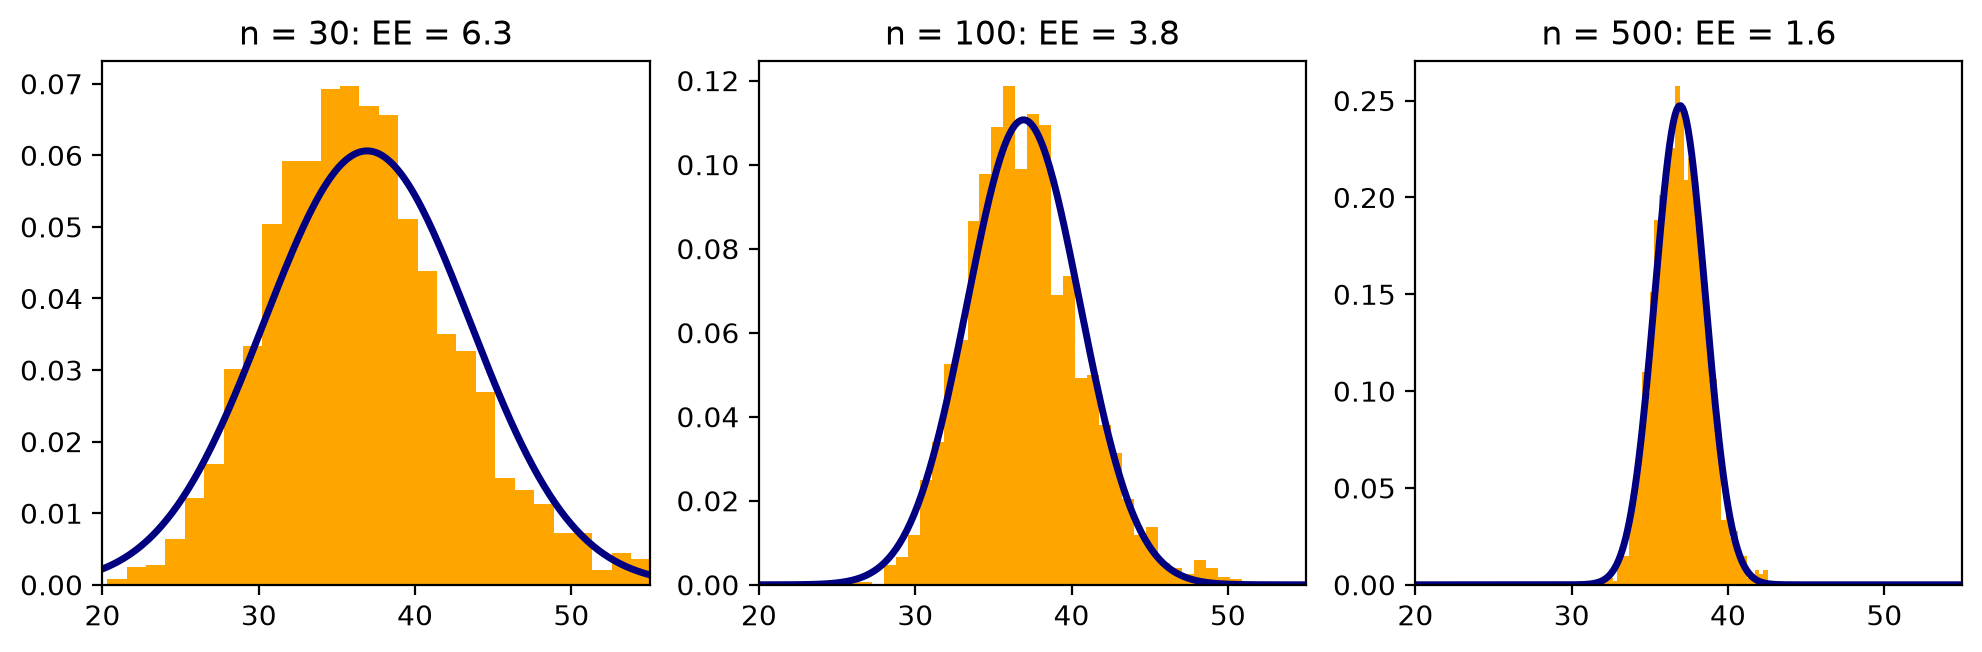

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for ax, n in zip(axes, [30, 100, 500]):
    medias_n = np.array([rng.choice(duracion, n).mean() for _ in range(2000)])
    ax.hist(medias_n, bins=40, density=True, color="orange")
    grilla = np.linspace(20, 55, 300)
    ax.plot(grilla, stats.norm.pdf(grilla, duracion.mean(), duracion.std() / np.sqrt(n)),
            color="navy", lw=2.5)
    ax.set(xlim=(20, 55), title=f"n = {n}: EE = {medias_n.std():.1f}")
plt.show()

Eso es el **teorema central del límite**: la media de una muestra se distribuye aproximadamente normal alrededor de la media de la población, con desviación $\sigma/\sqrt{n}$, **aunque la variable original no sea normal** (la duración tiene una cola larguísima y aun así las medias son una campana). Con $n$ pequeño la aproximación es más gruesa; con $n$ grande es casi perfecta. Por eso la normal es la distribución de la inferencia: no porque los datos sean normales, sino porque los promedios lo son.

## 4. Primer uso del error estándar: el intervalo de confianza

**Objetivo:** convertir el error estándar en un rango honesto para la media de la población, a partir de una sola muestra.

El puente tiene dos pasos. **Paso 1:** por el teorema central del límite las medias muestrales son normales, así que la regla de la normal se les aplica: el 95% de las medias muestrales cae a menos de $1{,}96$ errores estándar de la media real. Lo comprobamos con las 2.000 medias de la sección anterior:

In [11]:
ee_teorico = duracion.std() / np.sqrt(100)
dentro = np.abs(medias - duracion.mean()) <= 1.96 * ee_teorico
print(f"Medias muestrales a menos de 1,96 EE de la media real: {dentro.mean():.1%}")

Medias muestrales a menos de 1,96 EE de la media real: 95.0%


**Paso 2** es decir la misma frase al revés: si la media de mi muestra está a menos de 1,96 EE de la media real, entonces la media real está a menos de 1,96 EE de la media de mi muestra. Como eso pasa en el 95% de las muestras, el rango

$$\bar{x} \pm 1{,}96 \cdot \frac{s}{\sqrt{n}}$$

atrapa a la media de la población en el 95% de las muestras. Aquí $\bar{x}$ es la media de la muestra, $s/\sqrt{n}$ su error estándar (con $s$ en lugar de $\sigma$, porque en la práctica no conocemos la población) y 1,96 el múltiplo de la normal que deja 95% al centro. Ese rango es el **intervalo de confianza del 95%**. Con una muestra de 100 viajes:

In [12]:
muestra = rng.choice(duracion, 100)
ee = muestra.std(ddof=1) / np.sqrt(100)
inferior, superior = muestra.mean() - 1.96 * ee, muestra.mean() + 1.96 * ee

print(f"media de la muestra: {muestra.mean():.1f} | EE: {ee:.2f}")
print(f"intervalo del 95%: [{inferior:.1f}, {superior:.1f}]")
print(f"media de la población: {duracion.mean():.1f} -> ¿cae dentro? {inferior <= duracion.mean() <= superior}")

media de la muestra: 40.0 | EE: 3.06
intervalo del 95%: [34.0, 46.0]
media de la población: 36.9 -> ¿cae dentro? True


La lectura correcta del 95% es sobre el **procedimiento**, no sobre este intervalo en particular: si repitiéramos el muestreo muchas veces, el 95% de los intervalos atraparía la media real. Como tenemos la población, lo podemos comprobar:

In [13]:
atrapan = 0
for _ in range(1000):
    m = rng.choice(duracion, 100)
    ee = m.std(ddof=1) / 10
    if m.mean() - 1.96 * ee <= duracion.mean() <= m.mean() + 1.96 * ee:
        atrapan += 1
print("Intervalos que atrapan la media real:", atrapan, "de 1000")

Intervalos que atrapan la media real: 925 de 1000


Cerca del 95% (un poco menos: con $n = 100$ y una variable de cola tan larga, la aproximación normal todavía es algo gruesa; con $n$ mayor se acerca al 95% exacto). Dibujemos 100 de esos intervalos:

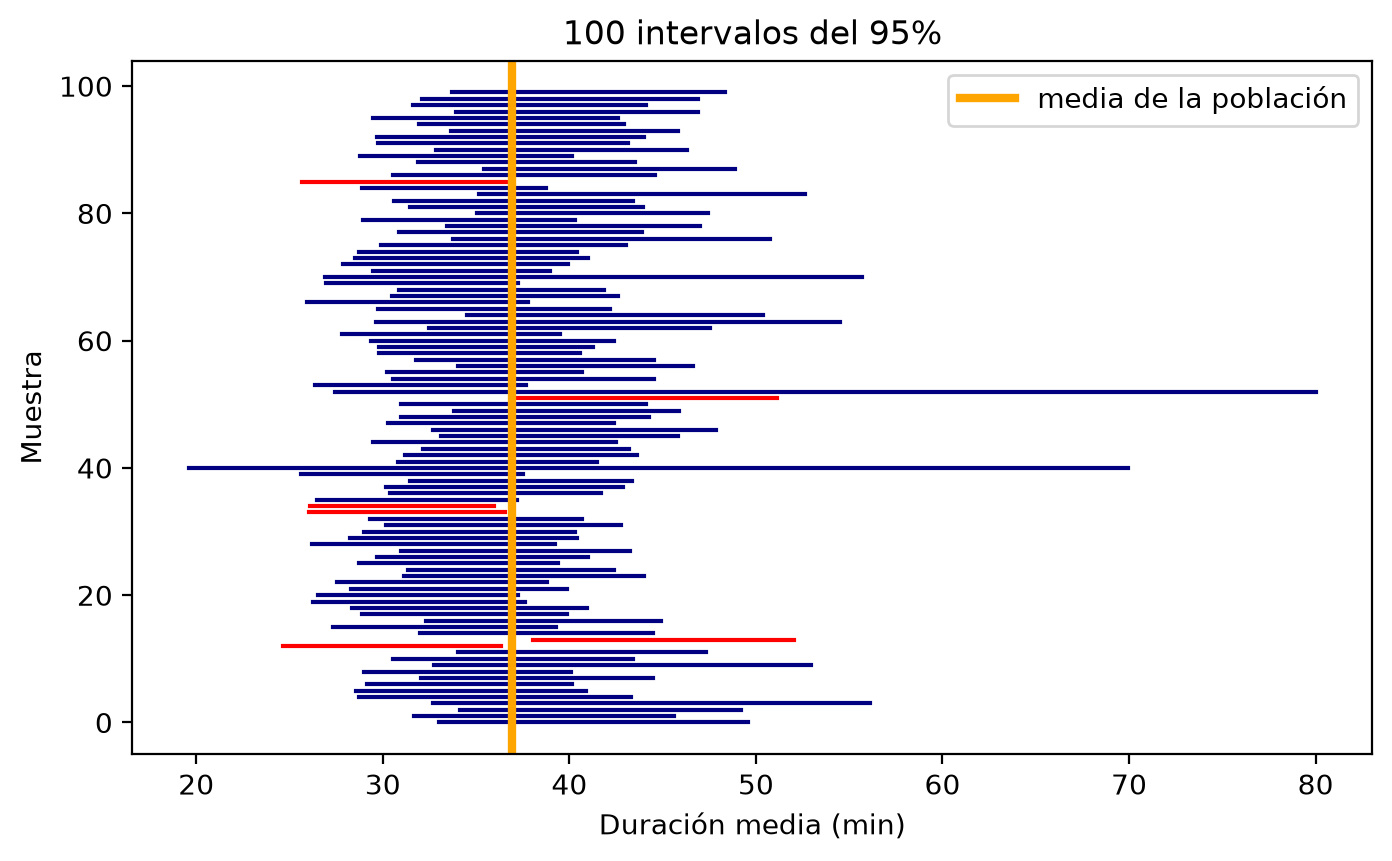

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(100):
    m = rng.choice(duracion, 100)
    ee = m.std(ddof=1) / 10
    inferior, superior = m.mean() - 1.96 * ee, m.mean() + 1.96 * ee
    atrapa = inferior <= duracion.mean() <= superior
    ax.plot([inferior, superior], [i, i], color="navy" if atrapa else "red", lw=1.5)
ax.axvline(duracion.mean(), color="orange", lw=3, label="media de la población")
ax.set(xlabel="Duración media (min)", ylabel="Muestra", title="100 intervalos del 95%")
ax.legend()
plt.show()

## 5. La pendiente también se mueve: bootstrap

**Objetivo:** ver cuánto se movería la pendiente de las comunas con otra muestra, y entender el error estándar que statsmodels imprime.

La pregunta pendiente desde la clase 3: la duración media de los viajes baja 4,8 minutos por cada millón de ingreso medio de la comuna, con 45 comunas. Esa pendiente, la $b$ de la recta $\text{duración} = a + b \cdot \text{ingreso}$ (el **coef** del ingreso en el summary), es un número que sale de una muestra, igual que la media de 100 viajes: con otras comunas saldría otra. Pero aquí no hay una población de comunas de donde sacar otra muestra. Reconstruimos la tabla por comuna de la clase 3 (ponderada, como entonces):

In [15]:
viajes_final = viajes.merge(hogares[["Hogar", "Comuna", "IngresoHogar"]], on="Hogar")
viajes_final = viajes_final.dropna(subset=["FactorLaboralNormal", "TiempoViaje", "IngresoHogar"]).copy()
w = viajes_final["FactorLaboralNormal"]
viajes_final["w_ingreso"] = w * viajes_final["IngresoHogar"]
viajes_final["w_duracion"] = w * viajes_final["TiempoViaje"]
suma = viajes_final.groupby("Comuna").sum(numeric_only=True)
por_comuna = pd.DataFrame({
    "ingreso": suma["w_ingreso"] / suma["FactorLaboralNormal"] / 1e6,
    "duracion": suma["w_duracion"] / suma["FactorLaboralNormal"],
    "n": viajes_final.groupby("Comuna").size()}).reset_index()
por_comuna = por_comuna[por_comuna["n"] >= 200]
len(por_comuna)

45

El **bootstrap** (Efron y Tibshirani, 1993) trata la muestra como si fuera la población: toma las 45 comunas, saca 45 **con reemplazo**, ajusta la recta, y lo repite miles de veces. Sacar con reemplazo significa sacar una comuna al azar, anotarla y devolverla a la bolsa antes de sacar la siguiente, de modo que puede volver a salir; no es quitar una comuna y poner otra. Así algunas comunas se repiten y otras quedan fuera. La distribución de las pendientes obtenidas es una estimación de la distribución muestral de la pendiente, sin suponer nada.

¿De dónde salen muestras distintas si solo hay 45 puntos? De sacar **con reemplazo**. Sin reemplazo no serviría: sacar 45 de 45 devuelve siempre las mismas 45 comunas y la misma recta. Con reemplazo cada extracción es independiente, así que una comuna puede salir dos o tres veces mientras otra no sale: es la forma de imitar otra muestra de 45 comunas de la ciudad, usando la muestra como si fuera la población. Veamos una:

In [16]:
x = por_comuna["ingreso"].values
y = por_comuna["duracion"].values
b_observada = np.polyfit(x, y, 1)[0]

# rng.integers: 45 índices al azar entre 0 y 44, con repetición
idx = rng.integers(0, len(x), len(x))
veces = np.bincount(idx, minlength=len(x))
print(pd.DataFrame({"comuna": por_comuna["Comuna"].values, "veces que salió": veces}).head(8))
print(f"no salieron: {(veces == 0).sum()} comunas | una vez: {(veces == 1).sum()} | dos o más: {(veces >= 2).sum()}")
print(f"pendiente observada: {b_observada:.2f} | pendiente de esta remuestra: {np.polyfit(x[idx], y[idx], 1)[0]:.2f}")

            comuna  veces que salió
0             BUIN                1
1  CALERA DE TANGO                1
2        CERRILLOS                1
3      CERRO NAVIA                2
4           COLINA                0
5         CONCHALI                1
6        EL BOSQUE                0
7         EL MONTE                0
no salieron: 13 comunas | una vez: 22 | dos o más: 10
pendiente observada: -4.81 | pendiente de esta remuestra: -5.54


Otros puntos, otra recta. Cinco remuestras más, para ver que cada una da una pendiente distinta:

In [17]:
for i in range(5):
    idx = rng.integers(0, len(x), len(x))
    print(f"remuestra {i + 1}: pendiente = {np.polyfit(x[idx], y[idx], 1)[0]:.2f}")

remuestra 1: pendiente = -8.18
remuestra 2: pendiente = -5.09
remuestra 3: pendiente = -4.25
remuestra 4: pendiente = -1.32
remuestra 5: pendiente = -7.40


Cinco pendientes distintas. ¿Y por qué 2.000 y no 30? Con 3 comunas A, B y C, sacar 3 con reemplazo da 10 remuestras distintas (AAA, AAB, AAC, ABB, ABC, ACC, BBB, BBC, BCC, CCC), cada una un conjunto de puntos distinto con su propia recta. Con 45 comunas hay más de $10^{25}$ remuestras posibles, así que 2.000 son todas distintas, y con unas 2.000 el error estándar deja de cambiar: es lo que hace falta para ver la forma completa de la distribución. Ahora sí, 2.000 veces:

In [18]:
pendientes = []
for _ in range(2000):
    idx = rng.integers(0, len(x), len(x))
    pendientes.append(np.polyfit(x[idx], y[idx], 1)[0])
pendientes = np.array(pendientes)

print(f"desviación de las 2000 pendientes (error estándar bootstrap): {pendientes.std():.2f}")
inferior, superior = np.percentile(pendientes, [2.5, 97.5])
print(f"intervalo bootstrap 95%: [{inferior:.2f}, {superior:.2f}]")
print(f"fracción de remuestras con pendiente >= 0: {np.mean(pendientes >= 0):.3f}")

desviación de las 2000 pendientes (error estándar bootstrap): 1.77
intervalo bootstrap 95%: [-9.05, -2.12]
fracción de remuestras con pendiente >= 0: 0.001


**Los percentiles.** `np.percentile(pendientes, [2.5, 97.5])` ordena las 2.000 pendientes y devuelve la que deja el 2,5% por debajo (la número 50 desde abajo) y la que deja el 2,5% por encima (la número 50 desde arriba). Entre ambas queda el 95% central de las remuestras: ese es el **intervalo bootstrap** del 95%, leído directo del histograma, sin suponer forma de campana.

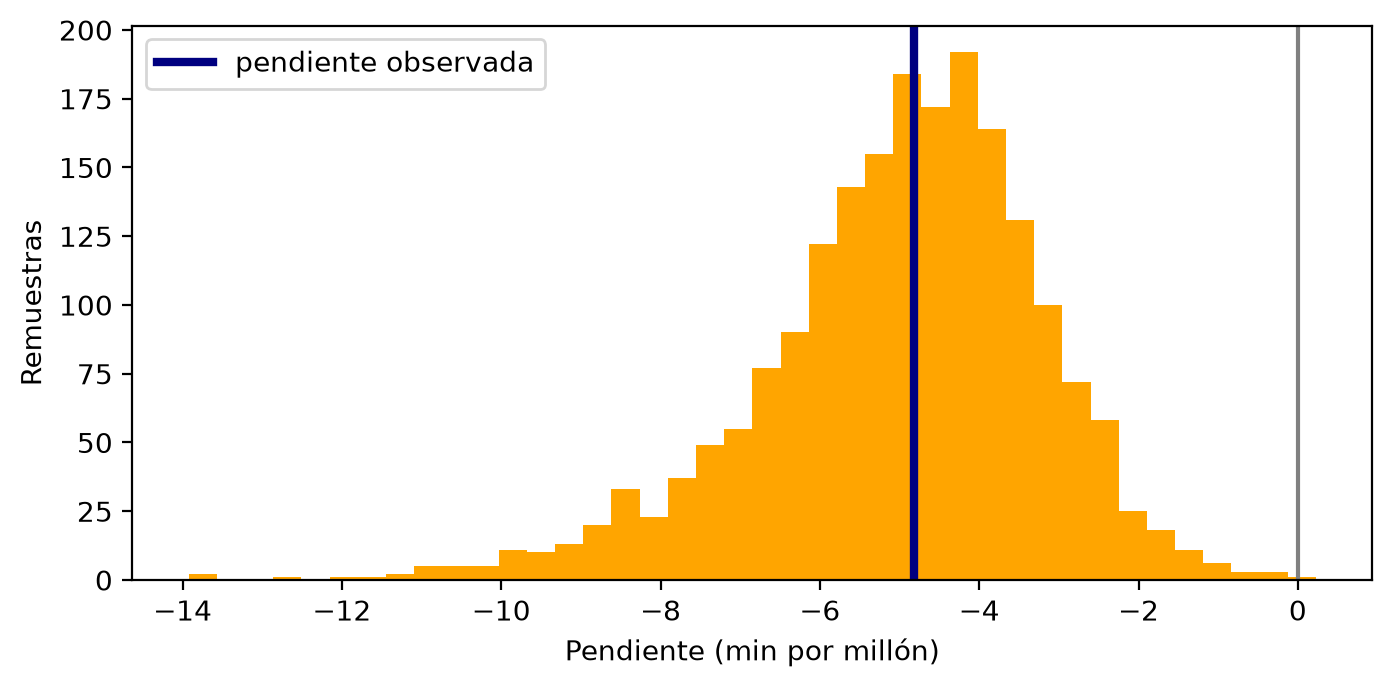

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(pendientes, bins=40, color="orange")
ax.axvline(b_observada, color="navy", lw=3, label="pendiente observada")
ax.axvline(0, color="gray", lw=1.5)
ax.set(xlabel="Pendiente (min por millón)", ylabel="Remuestras")
ax.legend()
plt.show()

Las 2.000 pendientes forman una campana alrededor de la observada (el teorema central del límite otra vez: un coeficiente es un promedio ponderado de los $y$). Su desviación es el **error estándar de la pendiente**, el mismo concepto que el de la media. Y casi ninguna remuestra llega al 0.

statsmodels calcula ese error estándar con una fórmula, a partir de los residuos y sin remuestrear: es la columna **std err** del summary que hasta ahora no leíamos:

In [20]:
modelo = sm.OLS(por_comuna["duracion"], sm.add_constant(por_comuna["ingreso"])).fit()
modelo.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,38.3352,1.773,21.622,0.000,34.760,41.911
ingreso,-4.8146,2.015,-2.389,0.021,-8.879,-0.750


Por ahora, tres columnas de la fila del ingreso:

- **coef** = −4,81: la pendiente.
- **std err** = 2,02: el error estándar de la pendiente, cerca del que dio el bootstrap.
- **[0.025, 0.975]** = [−8,9; −0,75]: el intervalo de confianza del 95% de la pendiente, coeficiente ± 2,02 · EE (2,02 en lugar de 1,96 por una razón que viene en la próxima sección). Es el primer uso del error estándar, ahora para la pendiente.

¿De dónde sale ese 2,02? De los residuos, con una fórmula:

$$EE(b) = \frac{s}{\sqrt{\sum_i (x_i - \bar{x})^2}}, \qquad s = \sqrt{\frac{\sum_i e_i^2}{n - 2}}$$

donde $e_i$ es el residuo de la comuna $i$ (su distancia vertical a la recta); $s$ es la desviación de esos residuos, que reemplaza a $\sigma$, la desviación de los errores alrededor de la recta verdadera, que no se conoce; $x_i - \bar{x}$ es cuánto se aleja el ingreso medio de cada comuna del ingreso medio de todas, y $n - 2$ son las 45 comunas menos los dos parámetros de la recta. La pendiente se mueve menos cuando las comunas están cerca de la recta ($s$ chico) y cuando los ingresos están bien desplegados (la suma grande). A mano:

In [21]:
residuos = modelo.resid
s_res = np.sqrt((residuos ** 2).sum() / (len(por_comuna) - 2))
sx = np.sqrt(((por_comuna["ingreso"] - por_comuna["ingreso"].mean()) ** 2).sum())

print(f"s, la desviación de los residuos: {s_res:.2f} min")
print(f"EE(b) = s / raíz(suma (x - x̄)²) = {s_res:.2f} / {sx:.2f} = {s_res / sx:.2f}")
print(f"std err de statsmodels: {modelo.bse['ingreso']:.2f}")

s, la desviación de los residuos: 5.50 min
EE(b) = s / raíz(suma (x - x̄)²) = 5.50 / 2.73 = 2.02
std err de statsmodels: 2.02


Los dos caminos al intervalo, comparados:

In [22]:
intervalo_formula = modelo.conf_int().loc["ingreso"]
print(f"bootstrap: [{inferior:.2f}, {superior:.2f}]")
print(f"fórmula:   [{intervalo_formula.iloc[0]:.2f}, {intervalo_formula.iloc[1]:.2f}]")

bootstrap: [-9.05, -2.12]
fórmula:   [-8.88, -0.75]


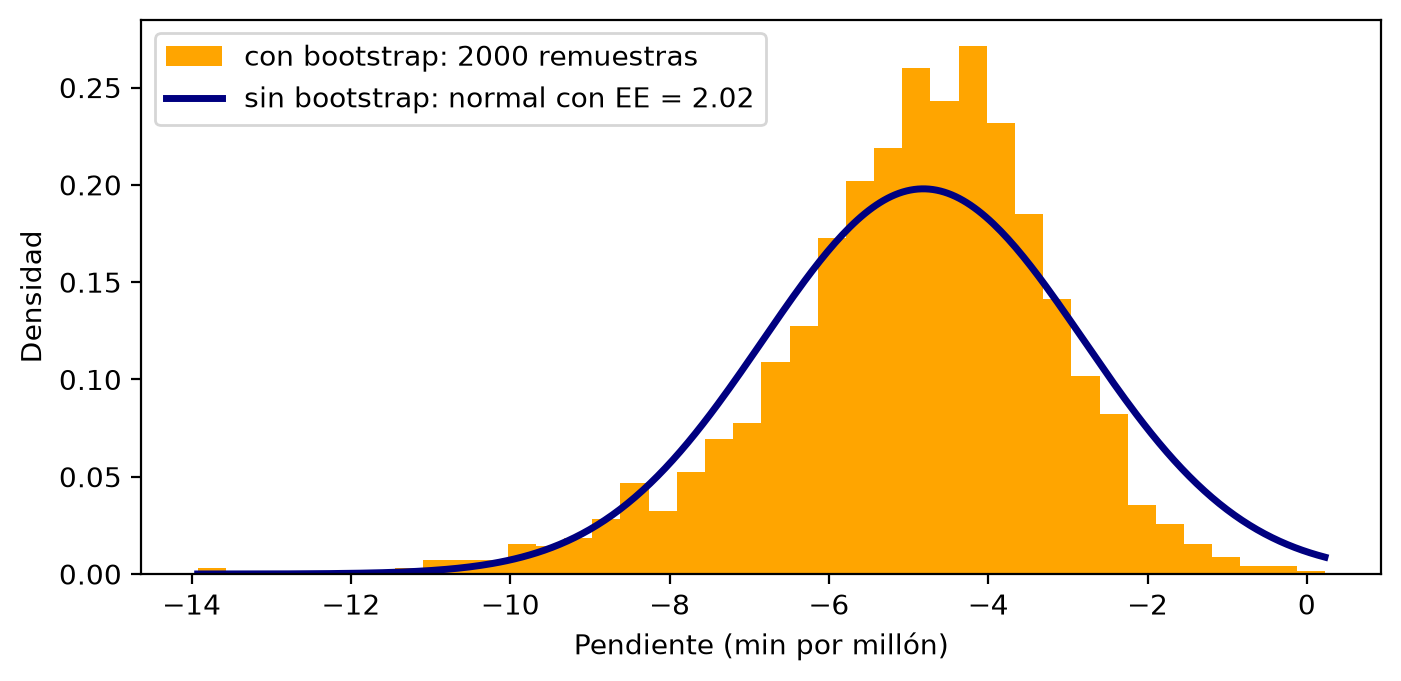

In [23]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(pendientes, bins=40, density=True, color="orange", label="con bootstrap: 2000 remuestras")
grilla = np.linspace(pendientes.min(), pendientes.max(), 300)
ee_formula = modelo.bse["ingreso"]
# stats.norm.pdf: la campana con la pendiente observada y el EE de la fórmula
ax.plot(grilla, stats.norm.pdf(grilla, b_observada, ee_formula), color="navy", lw=2.5,
        label=f"sin bootstrap: normal con EE = {ee_formula:.2f}")
ax.set(xlabel="Pendiente (min por millón)", ylabel="Densidad")
ax.legend()
plt.show()

Y en una tabla, para comparar de un vistazo:

In [24]:
pd.DataFrame({
    "sin bootstrap (fórmula)": [round(b_observada, 2), round(ee_formula, 2),
                               f"[{intervalo_formula.iloc[0]:.2f}, {intervalo_formula.iloc[1]:.2f}]"],
    "con bootstrap": [round(b_observada, 2), round(pendientes.std(), 2),
                      f"[{inferior:.2f}, {superior:.2f}]"],
}, index=["pendiente", "error estándar", "intervalo 95%"])

,sin bootstrap (fórmula),con bootstrap
pendiente,-4.81,-4.81
error estándar,2.02,1.77
intervalo 95%,"[-8.88, -0.75]","[-9.05, -2.12]"


Se parecen, y ninguno incluye el 0. El bootstrap sirve para cualquier estadístico (una mediana, una razón, un coeficiente de un modelo complicado) y no necesita fórmula ni supuestos; la fórmula es instantánea, pero supone cosas sobre los residuos que veremos al final de la próxima sección.

## 6. Segundo uso del error estándar: la prueba de hipótesis y el valor p

**Objetivo:** responder por fin si la pendiente de −4,8 es real o podría ser azar de 45 puntos.

**Qué tiene que ver el valor p con la regresión.** La recta resume 45 puntos, y esos puntos son una muestra: con otra encuesta los promedios por comuna serían otros y la recta también. En el mundo donde no hay relación (pendiente real 0), el azar igual inclina la recta ajustada: sus pendientes forman una campana centrada en 0 cuya desviación es el error estándar, 2,02, y por la regla del 95% de la normal casi todas quedan a menos de 2 errores estándar, ±4. La nuestra está a 2,4 errores estándar del cero: el azar logra eso el 2,1% de las veces, y ese es el valor p. Como es raro, concluimos que la relación probablemente es real. El summary hace la misma pregunta a cada coeficiente: ¿podría ser cero?

La campana del azar, dibujada en unidades de pendiente. Es la misma campana de la sección 5 (el histograma bootstrap, o la normal con el error estándar), pero centrada en 0 en vez de en la pendiente observada: allá preguntábamos cuánto se mueve nuestra pendiente; aquí, qué haría el azar si no hubiera relación:

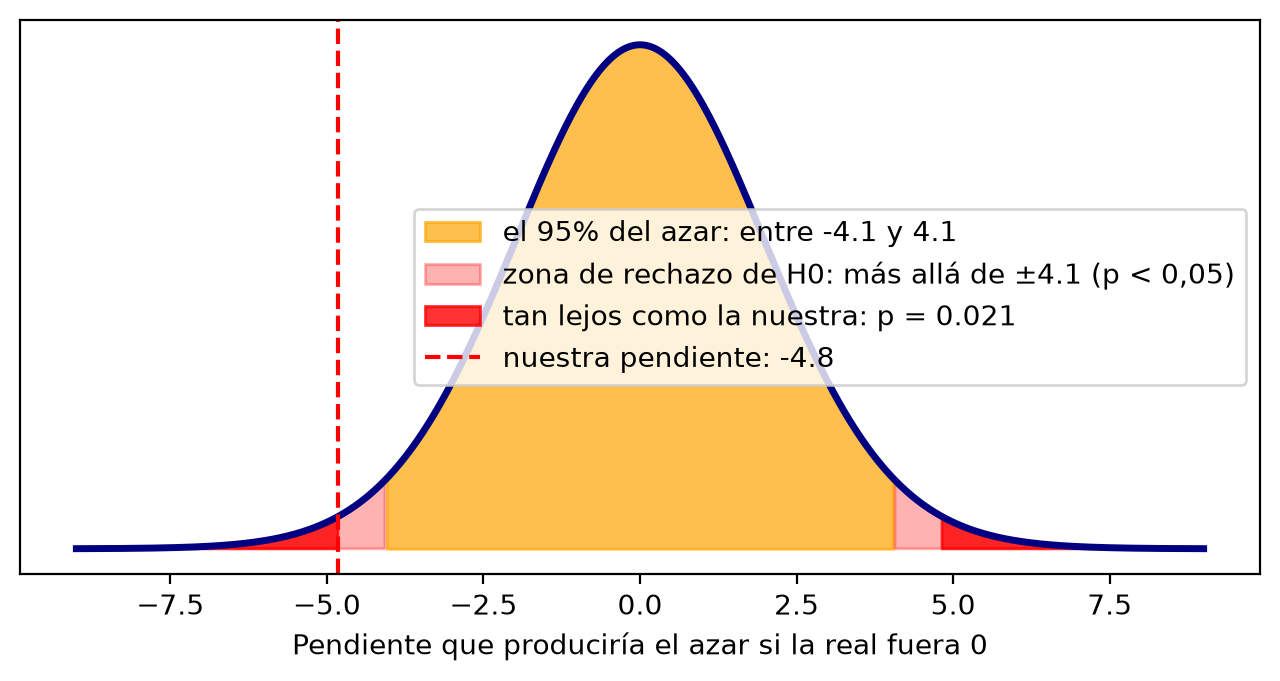

In [25]:
b, ee_b = modelo.params["ingreso"], modelo.bse["ingreso"]
gl = len(por_comuna) - 2
grilla = np.linspace(-9, 9, 600)
# La t de Student con gl grados de libertad, escalada por el error estándar
campana = stats.t.pdf(grilla / ee_b, gl) / ee_b

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(grilla, campana, color="navy", lw=2.5)
corte = stats.t.ppf(0.975, gl) * ee_b
ax.fill_between(grilla, campana, where=np.abs(grilla) <= corte, color="orange", alpha=0.7,
                label=f"el 95% del azar: entre {-corte:.1f} y {corte:.1f}")
ax.fill_between(grilla, campana, where=np.abs(grilla) >= corte, color="red", alpha=0.3,
                label=f"zona de rechazo de H0: más allá de ±{corte:.1f} (p < 0,05)")
ax.fill_between(grilla, campana, where=np.abs(grilla) >= abs(b), color="red", alpha=0.8,
                label=f"tan lejos como la nuestra: p = {modelo.pvalues['ingreso']:.3f}")
ax.axvline(b, color="red", ls="--", label=f"nuestra pendiente: {b:.1f}")
ax.set(xlabel="Pendiente que produciría el azar si la real fuera 0", yticks=[])
ax.legend()
plt.show()

La prueba de hipótesis formal: la **hipótesis nula** $H_0$ es "la pendiente real es 0" (el ingreso no tiene efecto); la **alternativa** $H_1$, que no lo es. La pregunta: si $H_0$ fuera cierta, ¿qué tan raro sería obtener una pendiente como la nuestra solo por el azar de qué comunas cayeron en la muestra?

Es la regla del 1,96 al revés. Si la pendiente real fuera 0, el 95% de las pendientes muestrales caería a menos de unos 2 errores estándar de 0. Así que el estadístico es

$$t = \frac{b}{EE(b)}$$

a cuántos errores estándar del cero está la pendiente $b$; $EE(b)$ es su error estándar. Y el **valor p** es la probabilidad, si $H_0$ fuera cierta, de un $t$ así de lejos de 0, por cualquiera de los dos lados. La convención es rechazar $H_0$ cuando $p < 0{,}05$.

### La t de Student

¿Con qué distribución se calcula ese valor p? Con la normal sería el 1,96. Pero el error estándar de $b$ se calculó con $s$, la desviación de los residuos de las 45 comunas, en lugar de $\sigma$, así que la distribución de $t$ es una normal con un margen extra: la **t de Student**, con $n - 2$ grados de libertad. Con 43 grados de libertad el 1,96 se vuelve 2,02; con $n$ grande son la misma cosa. Calculemos t y p a mano:

In [26]:
b, ee_b = modelo.params["ingreso"], modelo.bse["ingreso"]
t = b / ee_b
# La distribución t con n - 2 grados de libertad; el valor p es el
# área de las dos colas más allá de |t|
gl = len(por_comuna) - 2
p = 2 * (1 - stats.t.cdf(abs(t), gl))

print(f"t = {b:.2f} / {ee_b:.2f} = {t:.2f}")
print(f"valor p = {p:.3f}")
print(f"intervalo 95%: {b - 2.02 * ee_b:.2f} a {b + 2.02 * ee_b:.2f}  (2,02 es el 1,96 de la t con {gl} gl)")

t = -4.81 / 2.02 = -2.39
valor p = 0.021
intervalo 95%: -8.89 a -0.74  (2,02 es el 1,96 de la t con 43 gl)


Y las dos columnas del summary que faltaban:

- **t** = −2,39: el coeficiente dividido por su error estándar. La pendiente está a 2,4 errores estándar del cero.
- **P>|t|** = 0,021: el valor p. Si la pendiente real fuera 0, la probabilidad de obtener un t así de lejos solo por azar es 2,1%.

Como $p = 0{,}021 < 0{,}05$, la pendiente **no parece azar**. Es la respuesta que debíamos desde la clase 3. En el contexto: la pendiente que nos dio el modelo no es azar; en las comunas de mayor ingreso los viajes duran menos, unos 4,8 minutos menos por cada millón de pesos de ingreso medio (entre 0,75 y 8,9).

**Intervalo y valor p dicen lo mismo.** Que el intervalo [−8,9; −0,75] no incluya el 0 y que $p < 0{,}05$ es la misma afirmación: $b$ está a más de 2,02 errores estándar del 0. El intervalo además muestra el tamaño y la precisión del efecto; por eso se prefiere.

Y la advertencia de la clase 4 sigue vigente: **que un efecto sea estadísticamente significativo no dice que sea grande**. Con 45 comunas la pendiente apenas cruza el umbral; con más comunas, el mismo efecto daría un p mucho menor. El valor p depende tanto del efecto como del tamaño de la muestra; el tamaño del efecto lo dice el coeficiente, y su precisión, el intervalo.

### Los supuestos de OLS para inferir

**Objetivo:** mirar en los datos los supuestos detrás de los $t$ y $p$ del summary.

Los $t$ y $p$ de la regresión por mínimos cuadrados (OLS) son válidos bajo tres supuestos sobre los **errores** (lo que la recta no explica): que son independientes entre filas, que tienen la misma varianza en todo el rango y, con $n$ chico, que son normales. No se supone que las variables sean normales. Los dos primeros se pueden mirar en los residuos. Volvamos al modelo log-log de la duración contra la distancia de la clase 3 y guardemos sus residuos:

In [27]:
distancias = pd.read_csv(BASE + "DistanciaViaje.csv", sep=";", decimal=",")
vd = viajes.merge(distancias, on="Viaje")
vd = vd[vd["DistEuclidiana"] >= 0].dropna(subset=["TiempoViaje"]).copy()
vd["DistKm"] = vd["DistEuclidiana"] / 1000
vd = vd[(vd["DistKm"] > 0) & (vd["DistKm"] <= 150) & (vd["TiempoViaje"] > 0)]

modelo_ll = sm.OLS(np.log10(vd["TiempoViaje"]), sm.add_constant(np.log10(vd["DistKm"]))).fit()
vd["residuo"] = modelo_ll.resid
print(f"R2: {modelo_ll.rsquared:.2f} | viajes: {len(vd)}")

R2: 0.53 | viajes: 102223


**Errores independientes:** cada fila debe aportar información propia. Si en una regresión del gasto del hogar sobre el ingreso, con 100 personas, 50 son parejas de la misma casa, comparten ingreso, gasto y residuo: hay 100 filas pero 50 residuos independientes, y OLS cuenta 100: el error estándar sale demasiado chico y los $t$ y los valores p quedan inflados (ver la slide 42). La corrección para datos agrupados (`cov_type="cluster"`) queda fuera del módulo; la advertencia, no.

**Misma varianza:** la dispersión de los residuos debería ser parecida en todo el rango de $x$. Comparemos, por tramo de distancia, la desviación estándar del residuo del modelo en minutos (clase 3) y del modelo en log:

In [28]:
modelo_min = sm.OLS(vd["TiempoViaje"], sm.add_constant(vd["DistKm"])).fit()
tramo = pd.cut(vd["DistKm"], [0, 1, 2, 5, 10, 20, 40])
comparacion = pd.DataFrame({
    "sd residuo (min)": modelo_min.resid.groupby(tramo, observed=True).std().round(1),
    "sd residuo (log10)": vd["residuo"].groupby(tramo, observed=True).std().round(2),
})
comparacion

,sd residuo (min),sd residuo (log10)
DistKm,,
"(0, 1]",16.7,0.34
"(1, 2]",25.1,0.28
"(2, 5]",25.6,0.26
"(5, 10]",30.2,0.23
"(10, 20]",34.0,0.21
"(20, 40]",44.7,0.22


En minutos la dispersión casi se triplica entre los viajes cortos y los largos; en log cambia mucho menos. Es otra razón del log de la clase 4: no solo endereza la relación, también empareja los residuos.

**Normalidad:** el supuesto es que los residuos sigan una normal (no las variables). Importa con pocos datos: con 45 comunas hay que mirar el histograma de residuos y los atípicos. Con $n$ grande deja de importar, porque el teorema central del límite hace el trabajo: un coeficiente es un promedio ponderado de los $y$, y los residuos de la motorización no son normales y aun así su pendiente, remuestreada, sí lo es.

## Por qué esto importa en ciencia de datos

Todo lo que entrega un modelo sale de una muestra: sus coeficientes, sus predicciones y las métricas con que se evalúa. Con otra muestra, todo eso cambia. Comparar dos modelos es comparar dos números que se mueven, y sin saber cuánto se mueven no se puede decir cuál es mejor. Un modelo que se ajusta demasiado a su muestra aprende el azar de esa muestra, y falla con datos nuevos; medir el movimiento es la forma de detectarlo. Las técnicas de las próximas clases, y del resto del diplomado, son maneras de medir y controlar ese movimiento.

## 7. Ejercicio 

Con los datos de su proyecto (o con la EOD si aún no los tiene):

1. Calcule el error estándar y el intervalo de confianza del 95% de la media de su variable objetivo.
2. Ajuste una regresión simple con statsmodels y lea la fila completa de su variable: coeficiente, error estándar, t, valor p e intervalo. ¿Qué concluye?
3. Obtenga el intervalo de la pendiente por bootstrap y compárelo con el de statsmodels.

In [29]:
# Su solución


---

**Próxima clase (jueves 10-sep):** regresión logística, para una respuesta que es sí o no, y cómo clasificar con ella. Recuerde: el primer análisis exploratorio se entrega el lunes 15 de septiembre.